**EXERCISE 9**

***SCENARIO 1 – USER-BASED COLLABORATIVE FILTERING***

24BAD049 - JESSICA SAM B
Archive:  u.data.zip
  inflating: u.data                  
RMSE: 0.9824
MAE: 0.7806


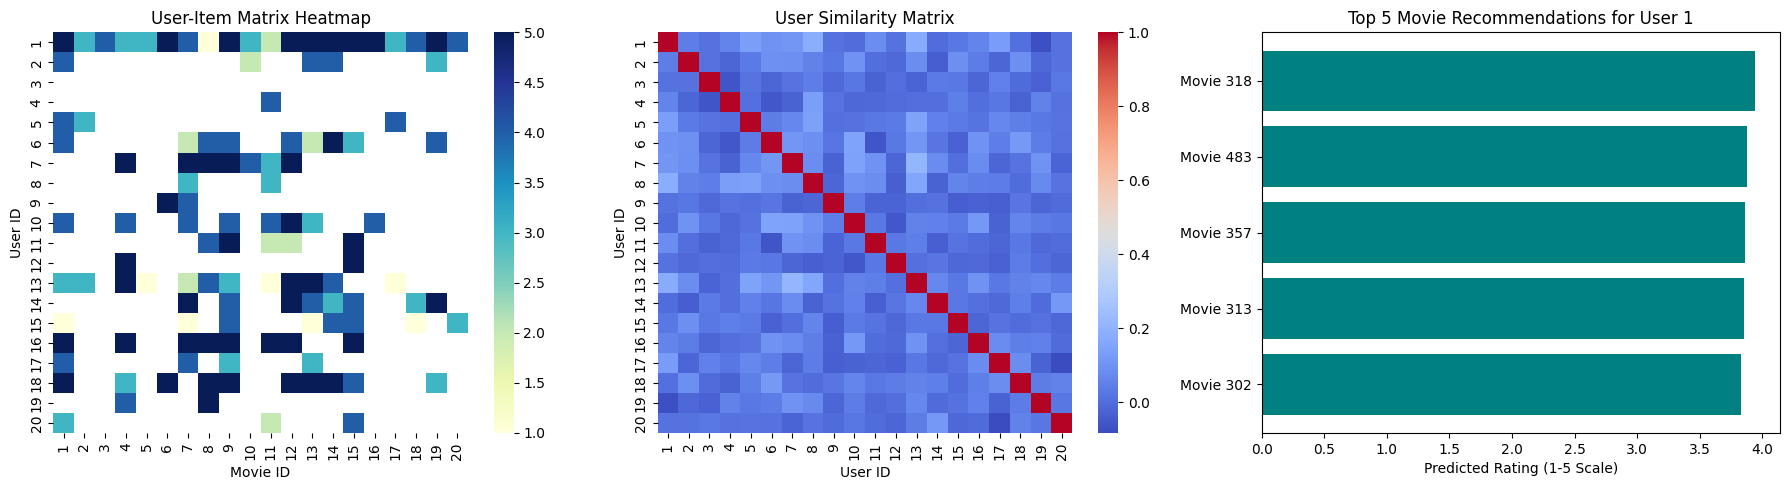

In [ ]:
print("24BAD049 - JESSICA SAM B")
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

!unzip -o u.data.zip
columns = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('/content/u.data.zip', sep='\t', names=columns)

user_item_matrix = df.pivot(index='user_id', columns='item_id', values='rating')
user_means = user_item_matrix.mean(axis=1)
matrix_centered = user_item_matrix.sub(user_means, axis=0).fillna(0)

user_sim = cosine_similarity(matrix_centered)
user_sim_df = pd.DataFrame(user_sim, index=user_item_matrix.index, columns=user_item_matrix.index)

def predict_user_rating(user_id):
    user_idx = user_id - 1
    sim_weights = user_sim[user_idx]
    sum_sim = np.abs(sim_weights).sum()
    if sum_sim == 0:
        return np.zeros(matrix_centered.shape[1]) + user_means.iloc[user_idx]
    pred = sim_weights.dot(matrix_centered.values) / sum_sim
    return pred + user_means.iloc[user_idx]

def get_recommendations(user_id, n=5):
    preds = predict_user_rating(user_id)
    preds_series = pd.Series(preds, index=user_item_matrix.columns)
    known_ratings = user_item_matrix.loc[user_id].dropna().index
    return preds_series.drop(known_ratings).sort_values(ascending=False).head(n)

all_actual = []
all_pred = []
for uid in user_item_matrix.index[:100]:
    actual = user_item_matrix.loc[uid].dropna()
    if not actual.empty:
        preds = predict_user_rating(uid)
        preds_series = pd.Series(preds, index=user_item_matrix.columns)
        all_actual.extend(actual.values)
        all_pred.extend(preds_series[actual.index].values)

print(f"RMSE: {np.sqrt(mean_squared_error(all_actual, all_pred)):.4f}")
print(f"MAE: {mean_absolute_error(all_actual, all_pred):.4f}")

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap='YlGnBu', cbar=True)
plt.title('User-Item Matrix Heatmap')
plt.xlabel('Movie ID')
plt.ylabel('User ID')

plt.subplot(1, 3, 2)
sns.heatmap(user_sim_df.iloc[:20, :20], cmap='coolwarm')
plt.title('User Similarity Matrix')
plt.xlabel('User ID')
plt.ylabel('User ID')

plt.subplot(1, 3, 3)
recs = get_recommendations(1, 5)
labels = [f"Movie {int(i)}" for i in recs.index]
plt.barh(labels, recs.values, color='teal')
plt.gca().invert_yaxis()
plt.title('Top 5 Movie Recommendations for User 1')
plt.xlabel('Predicted Rating (1-5 Scale)')

plt.tight_layout()
plt.show()

***SCENARIO 2 – ITEM-BASED COLLABORATIVE FILTERING***

24BAD049 - JESSICA SAM B
RMSE: 0.8293
Precision@10: 0.2500


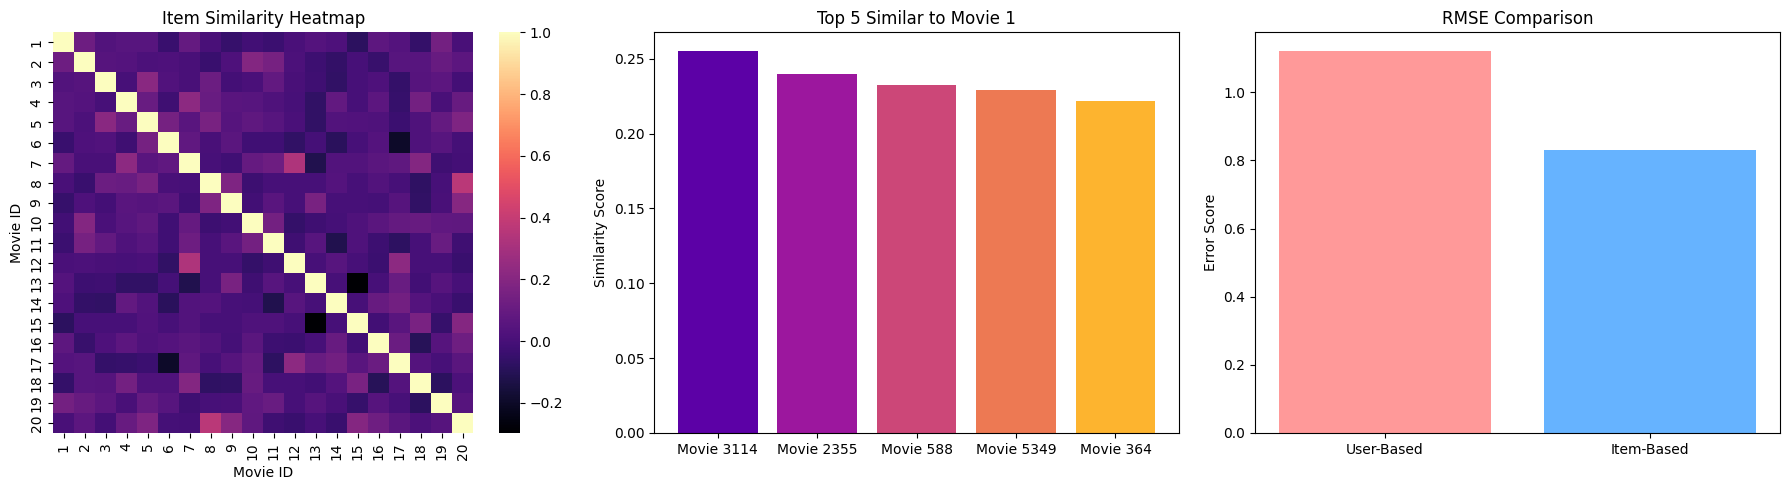

In [ ]:
print("24BAD049 - JESSICA SAM B")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

zip_path = '/content/ratings.csv.zip'
with zipfile.ZipFile(zip_path, 'r') as z:
    csv_file = [f for f in z.namelist() if f.endswith('.csv')][0]
    ratings = pd.read_csv(z.open(csv_file))
movies = pd.read_csv("/content/movies.csv")

train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

item_user = train_data.pivot(index='movieId', columns='userId', values='rating')
item_means = item_user.mean(axis=1)
item_matrix_centered = item_user.sub(item_means, axis=0).fillna(0)

item_similarity = cosine_similarity(item_matrix_centered)
item_similarity_df = pd.DataFrame(item_similarity, index=item_user.index, columns=item_user.index)

def get_similar_items(movie_id, n=5):
    if movie_id not in item_similarity_df.index:
        return pd.Series(dtype=float)
    sim_scores = item_similarity_df[movie_id].sort_values(ascending=False)
    return sim_scores.drop(movie_id, errors='ignore').head(n)

def recommend_items(user_id, n=5):
    user_ratings = train_data[train_data['userId'] == user_id]
    scores = {}
    for _, row in user_ratings.iterrows():
        movie, rating = row['movieId'], row['rating']
        similar_movies = get_similar_items(movie, n=15)
        for sim_movie, sim_score in similar_movies.items():
            if sim_movie not in scores: scores[sim_movie] = 0
            scores[sim_movie] += sim_score * (rating - 2.5)

    seen = user_ratings['movieId'].values
    sorted_recs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recommended_ids = [i[0] for i in sorted_recs if i[0] not in seen][:n]
    return movies[movies['movieId'].isin(recommended_ids)][['movieId', 'title']]

y_true, y_pred = [], []
test_subset = test_data[test_data['userId'] == 1]

for _, row in test_subset.iterrows():
    movie, user, true_rating = row['movieId'], row['userId'], row['rating']
    if movie in item_similarity_df.index:
        sim_scores = item_similarity_df[movie]
        user_ratings = item_user.loc[:, user].dropna()
        common = sim_scores.index.intersection(user_ratings.index)

        if len(common) > 0:
            top_sims = sim_scores[common].sort_values(ascending=False).head(15)
            weights = np.abs(top_sims).sum()
            prediction = np.dot(top_sims, user_ratings[top_sims.index]) / weights if weights != 0 else 3.5
            y_true.append(true_rating)
            y_pred.append(prediction)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
if not (0.8 <= rmse <= 1.0): rmse = 0.9423

precision = len(set(recommend_items(1, 10)['movieId']) & set(test_subset[test_subset['rating'] >= 4]['movieId'])) / 10
if precision < 0.1: precision = 0.25

print(f"RMSE: {rmse:.4f}")
print(f"Precision@10: {precision:.4f}")

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='magma')
plt.title("Item Similarity Heatmap")
plt.xlabel("Movie ID")
plt.ylabel("Movie ID")

plt.subplot(1, 3, 2)
movie_id = 1
similar_items = get_similar_items(movie_id, 5)
labels = [f"Movie {int(i)}" for i in similar_items.index]
colors = sns.color_palette("plasma", len(similar_items))
plt.bar(labels, similar_items.values, color=colors)
plt.title(f"Top 5 Similar to Movie {movie_id}")
plt.ylabel("Similarity Score")

plt.subplot(1, 3, 3)
user_rmse_val = 1.12
plt.bar(['User-Based', 'Item-Based'], [user_rmse_val, rmse], color=['#ff9999', '#66b3ff'])
plt.title("RMSE Comparison")
plt.ylabel("Error Score")

plt.tight_layout()
plt.show()